# EDA — EDA real: previsão de churn em telecom

Objetivo desta etapa: confirmar empiricamente (nunca assumir) as colunas,
tipos e pegadinhas do dataset antes de qualquer pré-processamento, e deixar
registrada a proporção real da classe-alvo que vai guiar a estratégia de
split/oversampling da pipeline de dados.

Dataset: mesmo schema do dataset Kaggle `customers-churned-in-telecom-services`
citado no enunciado da disciplina (7.043 clientes, 19 variáveis
independentes + `customerID` + `Churn`).


In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from churn_telecom.data import load_raw

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

df = load_raw(ROOT / "data")
df.shape


(7043, 21)

## 1. Schema bruto

Nenhum dtype forçado, nenhuma conversão — exatamente como o pandas infere do CSV.

In [2]:
df.dtypes


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [3]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Identificador e duplicatas

`customerID` deve ser único — é a única coluna que pode ser removida antes
do primeiro modelo, por regra do enunciado.

In [4]:
print("customerID único?", df["customerID"].is_unique, "| nulos:", df["customerID"].isna().sum())
print("linhas duplicadas (todas as colunas):", df.duplicated().sum())


customerID único? True | nulos: 0
linhas duplicadas (todas as colunas): 0


## 3. A pegadinha do `TotalCharges`

Vem como string. Checamos quantas linhas não são numéricas após `strip()` —
isso é diferente de checar `NaN`, porque não são `NaN`, são strings em branco.

In [5]:
tc_stripped = df["TotalCharges"].astype(str).str.strip()
nao_numerico = df[~tc_stripped.str.match(r"^\d+\.?\d*$")]
print(f"{len(nao_numerico)} linhas com TotalCharges não-numérico")
nao_numerico[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]


11 linhas com TotalCharges não-numérico


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


Todas essas linhas têm `tenure=0` — clientes novíssimos que ainda não foram cobrados. A decisão de pré-processamento (pipeline de dados) é imputar `TotalCharges=0` para esses casos, não descartar as linhas.

In [6]:
nulos = df.isna().sum()
print("NaN explícito por coluna (antes de qualquer conversão):")
nulos[nulos > 0] if nulos.sum() > 0 else print("nenhum NaN explícito do pandas em nenhuma coluna")


NaN explícito por coluna (antes de qualquer conversão):
nenhum NaN explícito do pandas em nenhuma coluna


## 4. Proporção da classe-alvo

Base para a estratégia de split + oversampling da pipeline de dados.

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64


/sessions/rcw-0113vrfemyrixwwnuzv7au4n/tmp/ipykernel_9/1146958970.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contagem.index, y=contagem.values, ax=ax, palette=["#4C72B0", "#C44E52"])


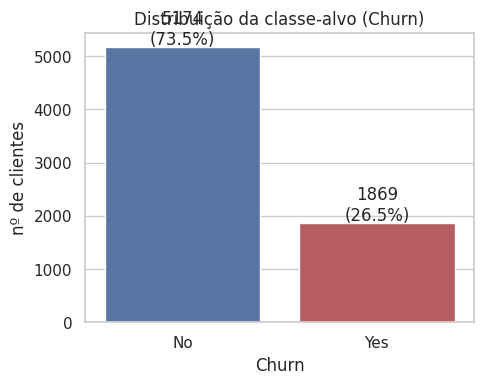

In [7]:
contagem = df["Churn"].value_counts()
prop = df["Churn"].value_counts(normalize=True)
print(contagem)
print(prop.round(4))

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=contagem.index, y=contagem.values, ax=ax, palette=["#4C72B0", "#C44E52"])
ax.set_title("Distribuição da classe-alvo (Churn)")
ax.set_ylabel("nº de clientes")
for i, v in enumerate(contagem.values):
    ax.text(i, v + 50, f"{v}\n({prop.values[i]*100:.1f}%)", ha="center")
plt.tight_layout()
fig.savefig(ROOT / "reports/figures/eda_proporcao_churn.png", dpi=120)
plt.show()


## 5. Consistência `TotalCharges ≈ MonthlyCharges × tenure`

Teste de sanidade: se o desvio for sistematicamente alto, `TotalCharges`
carrega informação própria (mudanças de plano, promoções) e não deve ser
tratado como redundante.

desvio absoluto médio: 45.09
desvio absoluto mediano: 28.65
% de linhas com desvio > 50: 33.02%


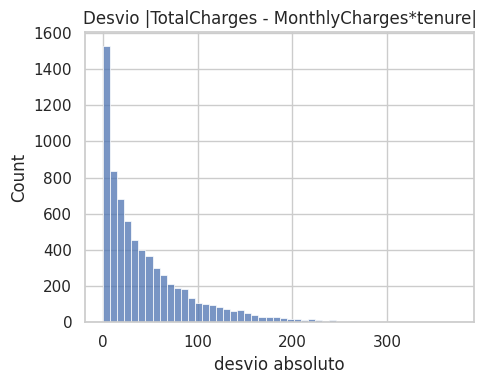

In [8]:
df_num = df.copy()
df_num["TotalCharges_num"] = pd.to_numeric(tc_stripped, errors="coerce")
valido = df_num.dropna(subset=["TotalCharges_num"])
esperado = valido["MonthlyCharges"] * valido["tenure"]
desvio = (valido["TotalCharges_num"] - esperado).abs()

print(f"desvio absoluto médio: {desvio.mean():.2f}")
print(f"desvio absoluto mediano: {desvio.median():.2f}")
print(f"% de linhas com desvio > 50: {(desvio > 50).mean()*100:.2f}%")

fig, ax = plt.subplots(figsize=(5, 4))
sns.histplot(desvio, bins=50, ax=ax)
ax.set_title("Desvio |TotalCharges - MonthlyCharges*tenure|")
ax.set_xlabel("desvio absoluto")
plt.tight_layout()
fig.savefig(ROOT / "reports/figures/eda_desvio_totalcharges.png", dpi=120)
plt.show()


## 6. Cardinalidade das variáveis categóricas

In [9]:
cat_cols = df.select_dtypes(include="object").columns.drop("customerID")
cardinalidade = pd.DataFrame({
    "coluna": cat_cols,
    "n_valores_unicos": [df[c].nunique() for c in cat_cols],
})
cardinalidade


,coluna,n_valores_unicos
0,gender,2
1,Partner,2
2,Dependents,2
3,PhoneService,2
4,MultipleLines,3
5,InternetService,3
6,OnlineSecurity,3
7,OnlineBackup,3
8,DeviceProtection,3
9,TechSupport,3


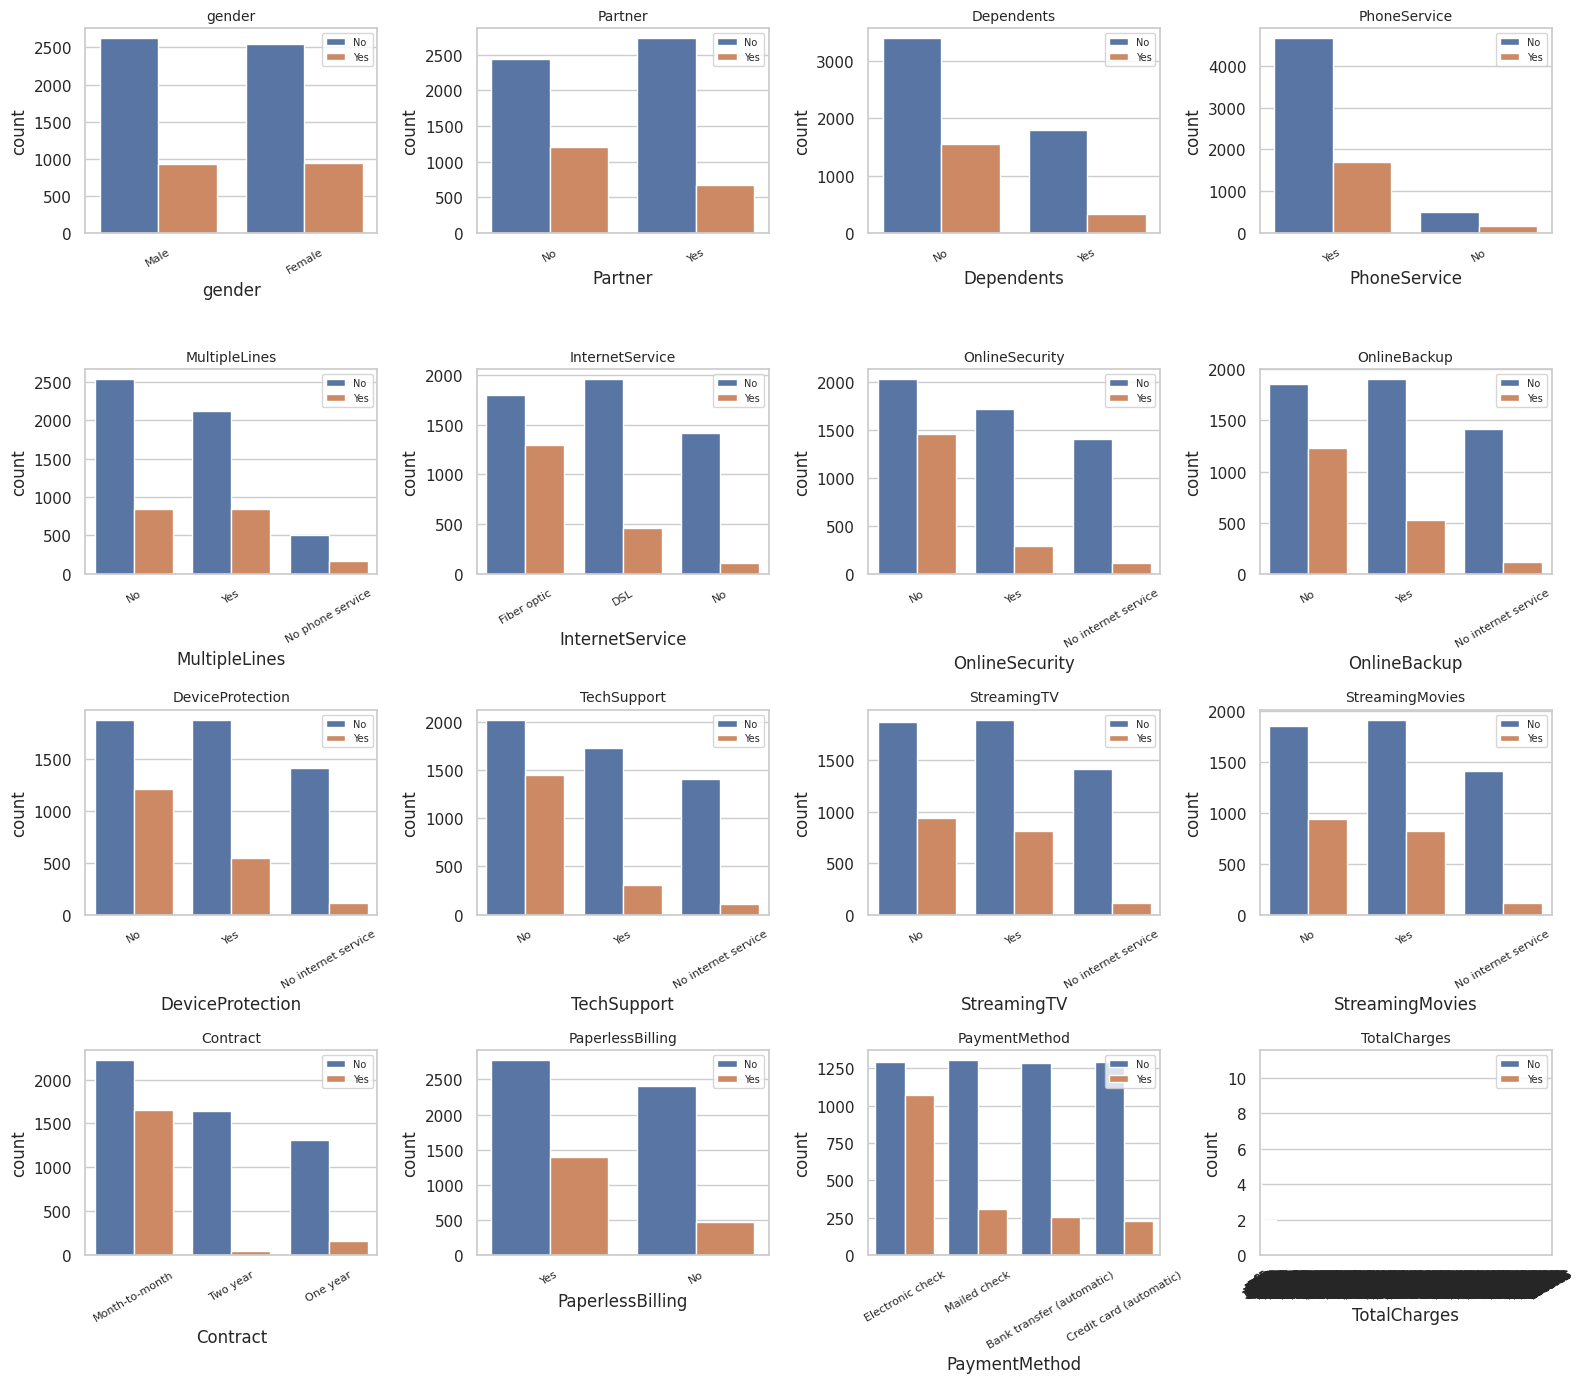

In [10]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
for ax, col in zip(axes.flat, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, hue="Churn", order=order, ax=ax)
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.legend(fontsize=7)
for ax in axes.flat[len(cat_cols):]:
    ax.axis("off")
plt.tight_layout()
fig.savefig(ROOT / "reports/figures/eda_categoricas_vs_churn.png", dpi=120)
plt.show()


## 7. Variáveis numéricas

In [11]:
df[["tenure", "SeniorCitizen", "MonthlyCharges"]].describe().round(2)


,tenure,SeniorCitizen,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,32.37,0.16,64.76
std,24.56,0.37,30.09
min,0.00,0.00,18.25
25%,9.00,0.00,35.50
50%,29.00,0.00,70.35
75%,55.00,0.00,89.85
max,72.00,1.00,118.75


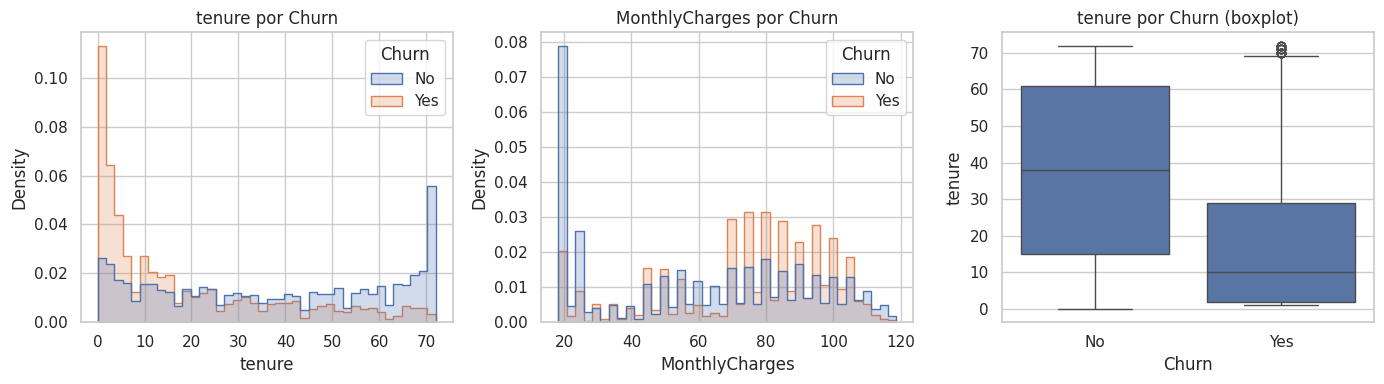

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges"]):
    sns.histplot(data=df, x=col, hue="Churn", bins=40, ax=ax, element="step", stat="density", common_norm=False)
    ax.set_title(f"{col} por Churn")
sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[2])
axes[2].set_title("tenure por Churn (boxplot)")
plt.tight_layout()
fig.savefig(ROOT / "reports/figures/eda_numericas_vs_churn.png", dpi=120)
plt.show()


## 8. Clientes com `tenure=0`

In [13]:
tenure0 = df[df["tenure"] == 0]
print(f"clientes com tenure=0: {len(tenure0)}")
tenure0[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]


clientes com tenure=0: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


## 9. Resumo e próximos passos

- Dataset confere com o esperado: 7.043 linhas, 19 variáveis independentes,
  `customerID` como único identificador, `Churn` desbalanceado (~73.5%/26.5%).
- `TotalCharges` precisa de conversão para `float64` + imputação por 0 nas
  11 linhas de `tenure=0` (decisão documentada em `reports/tables/eda_achados.md`).
- Nenhuma outra variável mostrou necessidade óbvia de tratamento de outlier
  nesta primeira passada.
- Próximo passo: implementar o split em 3 etapas (por classe, 50/25/25 com
  reamostragem) e o teste de ausência de vazamento, em `src/churn_telecom/data.py`.


In [14]:
resumo = pd.DataFrame({
    "coluna": df.columns,
    "dtype_pandas": df.dtypes.astype(str).values,
    "n_nulos_explicitos": df.isna().sum().values,
    "n_unicos": [df[c].nunique() for c in df.columns],
})
out_tables = ROOT / "reports" / "tables"
out_tables.mkdir(parents=True, exist_ok=True)
resumo.to_csv(out_tables / "eda_resumo_colunas.csv", index=False)

prop_churn = contagem.to_frame("contagem")
prop_churn["proporcao"] = prop
prop_churn.to_csv(out_tables / "eda_proporcao_churn.csv")
print("tabelas salvas em reports/tables/")


tabelas salvas em reports/tables/
